In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
from huggingface_hub import login
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer
import torch
import mlflow

/opt/conda/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-11-28 11:58:11.453086: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-28 11:58:11.472099: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-28 11:58:11.478214: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-28 11:58:11.492700: I tensorflow/core/platfor

INFO 11-28 11:58:14 [__init__.py:239] Automatically detected platform cuda.


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [4]:
model_name = "Llama-3.1-8B-Instruct"
developer_initials = "JP"

In [5]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "llm"
test_data_path = current_dir.parent.parent / "data/01_processed/pan21-authorship-verification-test.jsonl"
test_data_truth_path = current_dir.parent.parent / "data/01_processed/pan21-authorship-verification-test-truth.jsonl"

Load environment variables
Get access to HuggingFace

In [6]:
load_dotenv(env_path)
huggingface_acess_token = os.getenv("huggingface_jp")

In [7]:
!nvidia-smi

Fri Nov 28 11:58:18 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:27:00.0 Off |                    0 |
|  0%   42C    P8             35W /  300W |       3MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
gpu_name = torch.cuda.get_device_name(0)
gpu_props = torch.cuda.get_device_properties(0)
gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)  # in GB

In [9]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

121

In [10]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Load dataset

In [11]:
test_data_file_size = os.path.getsize(test_data_path)
test_data = []

with open(test_data_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 873M/873M [00:02<00:00, 307MB/s] 


Successfully loaded 19999 items.


Load the data into the pandas dataframe

In [12]:
test_data_df = pd.DataFrame(test_data)
test_data_df.drop(columns=['fandoms'], inplace=True)
print(test_data_df.head())

                                     id  \
0  c28e8b03-c02a-5184-b58a-12dd28b8ca74   
1  b9326101-6352-56dd-9d1b-1f41466897b7   
2  e2ac4453-bf54-53f2-bf68-6caae6aacded   
3  a5e9a289-0999-5764-b597-dc1bf8c21ede   
4  cb4054b1-d422-58d6-a137-dcfc70100df6   

                                                pair  
0  [talk because they hadn"t been exposed to comm...  
1  [Zazuki nodded his head and got to his feet, k...  
2  ["Oh we did lots of special things. On Christm...  
3  ["Hey now, at least Shido brings home some mon...  
4  [It was a mere five minutes" walk from third y...  


Load the testing set labels

In [13]:
test_data_truth_file_size = os.path.getsize(test_data_truth_path)
test_data_truth = []

with open(test_data_truth_path, 'r') as f:
    with tqdm(total=test_data_truth_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data_truth.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data_truth)} items.")

Loading data: 100%|██████████| 1.91M/1.91M [00:00<00:00, 40.4MB/s]


Successfully loaded 19999 items.


Load the data into pandas dataframe

In [14]:
test_data_truth_df = pd.DataFrame(test_data_truth)
test_data_truth_df.drop(columns=['authors'], inplace=True)
print(test_data_truth_df.head())

                                     id   same
0  c28e8b03-c02a-5184-b58a-12dd28b8ca74   True
1  b9326101-6352-56dd-9d1b-1f41466897b7   True
2  e2ac4453-bf54-53f2-bf68-6caae6aacded  False
3  a5e9a289-0999-5764-b597-dc1bf8c21ede   True
4  cb4054b1-d422-58d6-a137-dcfc70100df6   True


Combine the dataframes for evaluation

In [15]:
test_data_full_df = pd.merge(test_data_df, test_data_truth_df, on='id')
test_data_full_reduced_df =  test_data_full_df.head(1)
print(test_data_full_df.head())

                                     id  \
0  c28e8b03-c02a-5184-b58a-12dd28b8ca74   
1  b9326101-6352-56dd-9d1b-1f41466897b7   
2  e2ac4453-bf54-53f2-bf68-6caae6aacded   
3  a5e9a289-0999-5764-b597-dc1bf8c21ede   
4  cb4054b1-d422-58d6-a137-dcfc70100df6   

                                                pair   same  
0  [talk because they hadn"t been exposed to comm...   True  
1  [Zazuki nodded his head and got to his feet, k...   True  
2  ["Oh we did lots of special things. On Christm...  False  
3  ["Hey now, at least Shido brings home some mon...   True  
4  [It was a mere five minutes" walk from third y...   True  


# Set up model

Log in to huggingface

In [16]:
login(huggingface_acess_token)

Load the model

In [17]:
model_id = "TheBloke/Llama-2-70B-chat-GPTQ"
tokenizer = AutoTokenizer.from_pretrained(model_id)
llama2 = LLM(model=model_id, 
             quantization='gptq')

INFO 11-28 11:58:37 [config.py:689] This model supports multiple tasks: {'reward', 'score', 'classify', 'embed', 'generate'}. Defaulting to 'generate'.
INFO 11-28 11:58:39 [gptq_marlin.py:147] Detected that the model can run with gptq_marlin, however you specified quantization=gptq explicitly, so forcing gptq. Use quantization=gptq_marlin for faster inference
WARNING 11-28 11:58:39 [config.py:768] gptq quantization is not fully optimized yet. The speed can be slower than non-quantized models.
INFO 11-28 11:58:39 [config.py:1901] Chunked prefill is enabled with max_num_batched_tokens=8192.
WARNING 11-28 11:58:40 [utils.py:2304] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/getting_started/troubleshooting.html#python-multiprocessing for more information. Reason: CUDA is initialized


/opt/conda/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-11-28 11:58:44.934572: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-28 11:58:44.951095: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-28 11:58:44.956495: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-28 11:58:44.969977: I tensorflow/core/platfor

INFO 11-28 11:58:47 [__init__.py:239] Automatically detected platform cuda.
INFO 11-28 11:58:51 [core.py:61] Initializing a V1 LLM engine (v0.8.4) with config: model='TheBloke/Llama-2-70B-chat-GPTQ', speculative_config=None, tokenizer='TheBloke/Llama-2-70B-chat-GPTQ', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=4096, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=gptq, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='auto', reasoning_backend=None), observability_config=ObservabilityConfig(show_hidden_metrics=False, otlp_traces_endpoint=None, collect_model_forward_time=False, collect_model_execute_time=False), seed=None, served_model_name=TheBloke/Llama-2-70B-chat-GPTQ, num_scheduler_steps=1, m

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:49<00:00, 49.58s/it]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:49<00:00, 49.59s/it]



INFO 11-28 11:59:44 [loader.py:458] Loading weights took 49.66 seconds
INFO 11-28 11:59:46 [gpu_model_runner.py:1291] Model loading took 32.8867 GiB and 52.898498 seconds
INFO 11-28 12:00:16 [backends.py:416] Using cache directory: /home//.cache/vllm/torch_compile_cache/f0f9845fe2/rank_0_0 for vLLM's torch.compile
INFO 11-28 12:00:16 [backends.py:426] Dynamo bytecode transform time: 30.15 s
INFO 11-28 12:00:18 [backends.py:115] Directly load the compiled graph for shape None from the cache
INFO 11-28 12:00:51 [monitor.py:33] torch.compile takes 30.15 s in total
INFO 11-28 12:01:01 [kv_cache_utils.py:634] GPU KV cache size: 14,320 tokens
INFO 11-28 12:01:01 [kv_cache_utils.py:637] Maximum concurrency for 4,096 tokens per request: 3.50x
INFO 11-28 12:02:32 [gpu_model_runner.py:1626] Graph capturing finished in 91 secs, took 2.10 GiB
INFO 11-28 12:02:33 [core.py:163] init engine (profile, create kv cache, warmup model) took 167.12 seconds
INFO 11-28 12:02:33 [core_client.py:435] Core engi

Set up the parameters for decoding responses

In [18]:
sampling_parameters = SamplingParams(temperature=0.0, top_p=1.0, max_tokens=4096)
sampling_parameters.use_prefix_caching = True

### Set up prompts

from [https://github.com/baixianghuang/authorship-llm/blob/main/code/github-verify-llama2-70b.ipynb](https://github.com/baixianghuang/authorship-llm/blob/main/code/github-verify-llama2-70b.ipynb)

In [19]:
prompt_message_format = """
Verify if the input texts were written by the same author.
Do not consider topic differences. Focus on grammatical styles. 
Analyze the writing styles of the input texts, disregarding the differences in topic and content. 
Focus on linguistic features such as phrasal verbs, modal verbs, punctuation, rare words, affixes, quantities, 
humor, sarcasm, typographical errors, and misspellings. 
"""

In [20]:
response_message_format = """
Respond with a JSON object including two key elements:
{
  "analysis": Reasoning behind your answer.,
  "answer":  A boolean (True/False) answer.
}
"""

In [21]:
llm_prompt = f"""
        <s>[INST] <<SYS>>
        {response_message_format}
        <</SYS>>
        
        {prompt_message_format}
        
        The two texts are provided below between XML-style tags.
        
        <TEXT1> </TEXT1> <TEXT2> </TEXT2>
        
        [/INST]
        """



# Evaluate model

from [https://github.com/baixianghuang/authorship-llm/blob/main/code/github-verify-llama2-70b.ipynb](https://github.com/baixianghuang/authorship-llm/blob/main/code/github-verify-llama2-70b.ipynb)

Evaluation function

In [22]:
def evaluate_results(y_test, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_test, y_pred)*100, 2)
    precision = round(precision_score(y_test, y_pred, average=average)*100, 2)
    recall = round(recall_score(y_test, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_test, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Evaluate model function

In [23]:
def evaluate_model(test_data_df, llm_model, prompt_message_format, response_message_format):
    start_time = time.time()
    verification_results = []
    
    def preprocess_text(text):
        tokens = tokenizer(
            text,
            truncation=True,
            max_length=1750,
            add_special_tokens=False
        )
        return tokenizer.decode(tokens['input_ids'], skip_special_tokens=True).strip()

    test_data_df = test_data_df.copy()
    test_data_df["text1_clean"] = test_data_df["pair"].apply(lambda x: preprocess_text(x[0]))
    test_data_df["text2_clean"] = test_data_df["pair"].apply(lambda x: preprocess_text(x[1]))

     
    for i in tqdm(test_data_df.index, desc="Processing rows"):
        resulting_df_row = {}
        resulting_df_row['id']  = test_data_df.loc[i, 'id']
        resulting_df_row['actual_result'] = test_data_df.loc[i, 'same']
        text1 = test_data_df.loc[i, 'text1_clean']
        text2 = test_data_df.loc[i, 'text2_clean']
        
        llm_prompt = f"""
        <s>[INST] <<SYS>>\n{response_message_format}\n<</SYS>>\n\n{prompt_message_format} 
        The input texts (Text 1 and Text 2) are delimited with triple backticks. ```Text 1: {text1}, \n\nText 2: {text2}```\n\n[/INST]
        """
        
        raw_response = llama2.generate(llm_prompt, sampling_parameters)
        response_str = raw_response[0].outputs[0].text.strip()
        
        resulting_df_row['reasoning'] = response_str
        
        if 'True' in response_str or 'true' in response_str:
            resulting_df_row['prediction'] = True
        elif 'False' in response_str or 'false' in response_str:
            resulting_df_row['prediction'] = False
        else:
            resulting_df_row['prediction'] = None 

        verification_results.append(resulting_df_row)

    result_df = pd.DataFrame(verification_results)

    print("--- Execution Time: %s seconds ---" % round(time.time() - start_time, 2))

    return result_df

Evaluate llama

In [24]:
result_df = evaluate_model(test_data_full_reduced_df, llama2, prompt_message_format, response_message_format)

Processing rows:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processing rows: 100%|██████████| 1/1 [00:30<00:00, 30.54s/it]

--- Execution Time: 30.59 seconds ---


In [25]:
cleaned_result_df = result_df.dropna()

In [26]:
y_test = cleaned_result_df['actual_result'].to_list()
y_pred = cleaned_result_df['prediction'].to_list()

Calculate the evaluation metrics

In [27]:
accuracy, precision, recall, f1 = evaluate_results(y_test, y_pred)
print(f"The results of evaluation are: \n Accuracy: {accuracy} \n Precision: {precision} \n Recall: {recall} \n F1 score: {f1}")

The results of evaluation are: 
 Accuracy: 0.0 
 Precision: 0.0 
 Recall: 0.0 
 F1 score: 0.0


/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Create the confusion matrix

Text(0.5, 1.0, 'Confusion Matrix: TheBloke/Llama-2-70B-chat-GPTQ')

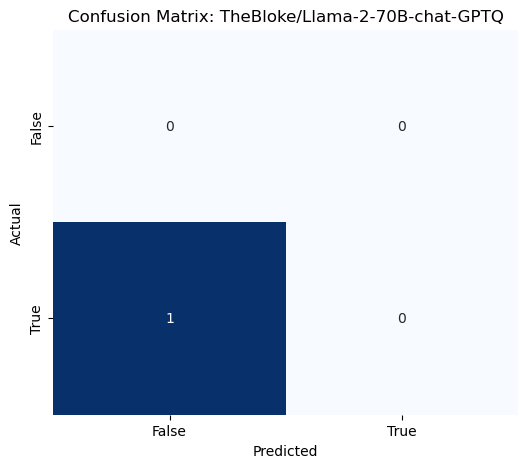

In [28]:
labels = [False, True] 
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=labels, 
            yticklabels=labels, 
            ax=ax,
            cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix: {model_id}')

Log model information + metrics + results table + confusion matrix

In [29]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")

mlflow.set_tracking_uri(results_path)
mlflow.set_experiment("JP-Authorship-Verification")
with mlflow.start_run(run_name=f"{results_path} / {date_str}_{developer_initials}_{model_name}_results"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("model_id ", model_id )
    mlflow.log_param("sampling_parameters", sampling_parameters)
    mlflow.log_param("prompt_message", prompt_message_format)
    mlflow.log_param("response_message", response_message_format)
    mlflow.log_param("llm_prompt", llm_prompt)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)

    mlflow.log_table(data=result_df, artifact_file="results.json")

    mlflow.log_figure(fig, "confusion_matrix.png")

/opt/conda/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
